In [22]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import gradio as gr
from sklearn.neural_network import MLPClassifier
import torchvision.datasets as datasets
import seaborn as sns
import cv2
from scipy import ndimage

# dark mode for seaborn
sns.set_style('darkgrid')

In [2]:
mnist_trainset = datasets.MNIST(root='./data', train=True, download=True, transform=None)
mnist_testset = datasets.MNIST(root='./data', train=False, download=True, transform=None)

100%|██████████| 9.91M/9.91M [00:01<00:00, 4.98MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 132kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.21MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 3.04MB/s]


In [4]:
print(mnist_trainset.data.shape)
print(mnist_testset.data.shape)
print(mnist_trainset.targets.shape)
print(mnist_testset.targets.shape)

torch.Size([60000, 28, 28])
torch.Size([10000, 28, 28])
torch.Size([60000])
torch.Size([10000])


In [6]:
X_train = mnist_trainset.data
y_train = mnist_trainset.targets
X_test = mnist_testset.data
y_test = mnist_testset.targets

In [7]:
X_train = X_train.numpy()
X_test = X_test.numpy()
y_train = y_train.numpy()
y_test = y_test.numpy()

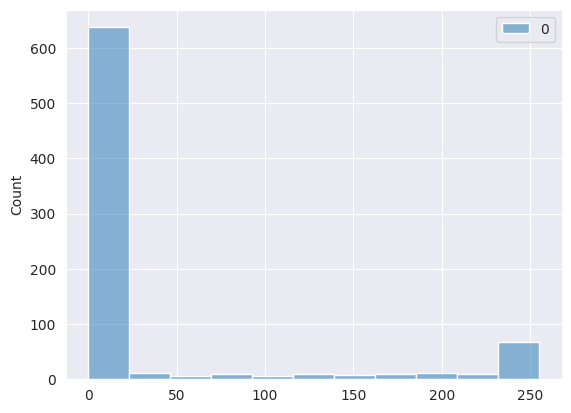

In [9]:
sns.histplot(data = X_train[0].reshape(784, 1))
plt.show()

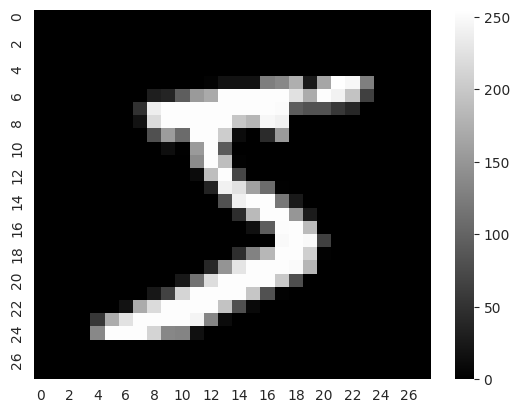

In [12]:
# plot first image
sns.heatmap(X_train[0], cmap = 'gray')
plt.show()

In [13]:
X_train = X_train.reshape(60000, 784) / 255
X_test = X_test.reshape(10000, 784) / 255

In [14]:
# train the model

In [15]:
mlp = MLPClassifier(hidden_layer_sizes=(100, 100, 100), max_iter=1000)
mlp.fit(X_train, y_train)

MLPClassifier(hidden_layer_sizes=(100, 100, 100), max_iter=1000)

In [16]:
# print the accuracies
print('Training Accuracy:   ', mlp.score(X_train, y_train))
print('Testing Accuracy:    ', mlp.score(X_test, y_test))

Training Accuracy:    1.0
Testing Accuracy:     0.9813


In [25]:
def predict(data):
    try:
        # 1. FIX THE "0" ISSUE: Extract and Invert colors
        # Sketchpad is Black-on-White; MNIST is White-on-Black
        img = data['composite']
        gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

        # This line flips the colors so the digit is white and background is black
        _, thresh = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY_INV)

        # 2. AUTO-CROP: Remove empty space around the digit
        coords = cv2.findNonZero(thresh)
        if coords is None: return "Draw something!"
        x, y, w, h = cv2.boundingRect(coords)
        digit = thresh[y:y+h, x:x+w]

        # 3. SCALE: Resize to 20x20 to match MNIST style
        if w > h:
            digit = cv2.resize(digit, (20, int(20 * h / w)))
        else:
            digit = cv2.resize(digit, (int(20 * w / h), 20))

        # 4. CENTER: Pad back to 28x28 and center the weight
        h, w = digit.shape
        top, left = (28 - h) // 2, (28 - w) // 2
        final_img = cv2.copyMakeBorder(digit, top, 28-h-top, left, 28-w-left,
                                       cv2.BORDER_CONSTANT, value=0)

        # Center of Mass shift for high accuracy
        cy, cx = ndimage.center_of_mass(final_img)
        M = np.float32([[1, 0, 14-cx], [0, 1, 14-cy]])
        final_img = cv2.warpAffine(final_img, M, (28, 28))

        # 5. INFERENCE: Flatten and predict
        final_flat = final_img.reshape(1, 784) / 255.0
        prediction = mlp.predict(final_flat)[0]

        return int(prediction)
    except Exception as e:
        return f"Error: {str(e)}"

gr.Interface(fn=predict, inputs=gr.Sketchpad(type="numpy"), outputs="label").launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://f6e4a3dd946e4122ab.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
